# 如何使用编译器：以LeNet-5为例

**LeNet-5简介：最早的卷积神经网络（CNN）之一，广泛用于图像识别。**

*张量结构：*
- **输入图像：** 32×32 像素，单通道
- **第一卷积层 C1：** 6 个 5×5 卷积滤波器，生成 6 个 28×28 的特征图 | ReLU 激活
- **平均池化层 AP2：** 2×2 核，步长为 2，生成 14×14 的特征图

## *如何使用 data_definition：*
**工具箱：** 矩阵操作需要安装 `numpy`：conda 环境下使用 `conda install numpy`

**定义矩阵尺寸：**
输入图像以大小为 32×32×1（高×宽×通道）的张量矩阵表示，经过卷积层 C1 后输出大小为 28×28×6 的张量。

为使用 VTA（例如进行矩阵乘法），我们通过 Im2row 方法将输入张量转换为二维矩阵：
得到输入矩阵 A（784×25）和权重矩阵 B（25×6），两者相乘得到大小为 784×6 的输出矩阵。此过程由 ACETONE 完成。

INP、WGT 和 OUT 矩阵的维度通过 `tensor_matrix_converter.py` 获取（仅计算维度，不生成矩阵）：

In [ ]:
"""导入必要的函数"""

%pip install numpy
import numpy as np
import sys
sys.path.append('../src/compiler/vta_compiler/data_definition')
import tensor_matrix_converter
import matrix_generator
import matrix_split
import matrix_multiplication

**VTA 要求：**
VTA 对输入矩阵的大小有固定要求。数据必须经过格式化，才能被模拟器使用。

以 LeNet-5 第一层为例，需要输入张量和滤波器的维度。下面的代码将逐步说明每个操作如何格式化输入数据。

我们来生成 INP、WGT（Im2Row 转换后）以及 OUT（矩阵乘法后）矩阵的维度。
用户需要修改以下输入张量和卷积核的维度参数：

In [ ]:
"""输入张量"""
input_channel = 1 # 用户设置
input_height = 32 # 用户设置
input_width = 32  # 用户设置

"""卷积核"""
kernel_channel = 6 # 滤波器数量 - 用户设置
kernel_height = 5  # 用户设置
kernel_width = 5   # 用户设置

"""计算参数（用于卷积）"""
stride_height = 1
stride_width = 1
pad_height = 0
pad_width = 0

使用 `tensor_matrix_converter.py`，可以打印卷积后输出张量的维度：

In [ ]:
"""输出张量"""
output_tensor_height, output_tensor_weight = tensor_matrix_converter.output_dimension(inp_dim=(input_height, input_width), \
                     wgt_dim=(kernel_height, kernel_width), \
                     stride=(stride_height, stride_width), \
                     padding=(pad_height, pad_width))

# 打印输入矩阵和权重矩阵的维度
tensor_matrix_converter.im2row_matrix_dimension(nc=input_channel, nh=input_height, nw=input_width, \
                            mc=kernel_channel, mh=output_tensor_height, mw=output_tensor_weight, \
                            fh=kernel_height, fw=kernel_width, \
                            sh=stride_height, sw=stride_width, \
                            ph= pad_height, pw=pad_width)

# 输入矩阵的尺寸
inp_height = output_tensor_height * output_tensor_weight
inp_width = input_channel * kernel_height * kernel_width
# 权重矩阵的尺寸
wgt_height = inp_width
wgt_width = kernel_channel
# 输出矩阵的尺寸
out_height = output_tensor_height * output_tensor_weight
out_width = kernel_channel

**配置数据生成：**
即是否随机化矩阵内容、是否进行填充、是否使用激活函数（ReLU）等。
通过 `user_configuration.py` 进行配置（将参数调整为 True 或 False）。

*例如，以下参数初始化 784×25 的输入矩阵 A 和 25×6 的权重矩阵 B，内容随机生成：*

```
isInitRandom = True
A_row = 784
A_col = 25
B_col = 6
```

*VTA 要求 16×16 的方阵进行乘法，之后使用 ReLU 激活：*

```
block_size = 16
isSquare = True
useReLU = True
```

*我们希望输出为二进制文件，因此：*

```
doWriteBinaryFile = True
```

In [ ]:
"""矩阵生成"""
# 是否用随机值初始化矩阵？（True / False）
isInitRandom = True
# 若是，random_bound 限制数值范围（int8 = [-128; 127] -> random_bound = 128）
random_bound = 4

"""计算规格"""
# 方阵乘法的块大小（两个 block_size 方阵相乘）
block_size = 16 # VTA 要求

# 是否使用方阵
isSquare = True

# 是否计算未填充的矩阵？（True / False）
doMultiplyNonPadded = False

# C 矩阵选项
# 从 int16 压缩到 int8：useClip（True / False）
# => True: 若 x > 0: 截断 => max(127, x)
# => False: 截断最高有效位
useClip = False

# 对结果应用 ReLU
useReLU = True


"""打印与文件输出功能"""
# 是否打印数据？（True / False）
doPrint = True

# 是否将矩阵写入 OUTPUT 目录的二进制文件？（True / False）
doWriteBinaryFile = True

**生成数据：**
程序 `main_matrix_generator.py` 可为 *functional_simulator* 和 *cycle_accurate_simulator* 生成二进制文件，文件保存在 *compiler_output/* 目录中。

它调用以下几个程序中的函数：
- `matrix_generator.py`：根据 `user_configuration.py` 生成输入矩阵和权重矩阵（A 大小 784×25，B 大小 25×6），包括矩阵的行列数、填充方式及是否随机初始化。A 和 B 将被填充为 784×32 和 32×16 以便分块。
- `matrix_split.py`：将 A 和 B 拆分为 16×16 的子块，满足 VTA 的矩阵乘法要求。
- `matrix_multiplication.py`：执行分块矩阵乘法。A_block_i（16×16）与 B_block_j（16×16）相乘，得到 16×16 的输出子矩阵。若使用 ReLU 函数，则对输出矩阵的每个值应用 ReLU。

首先，根据前面输入的维度生成输入矩阵和权重矩阵。

In [ ]:
# ----------------------
# 用随机值生成矩阵 A 和 B

# 输入矩阵 A
input_matrix = matrix_generator.matrix_creation(n_row=inp_height, n_col=inp_width, isInitRandom=isInitRandom, random_bound=random_bound)

# 权重矩阵 B
weight_matrix = matrix_generator.matrix_creation(n_row=inp_width, n_col=wgt_width, isInitRandom=isInitRandom, random_bound=random_bound)

print("输入矩阵 (",inp_height, "x", inp_width,") :\n", input_matrix)
print("权重矩阵 (",inp_width, "x", wgt_width,") :\n", weight_matrix)

#### 填充（PADDING）

VTA 要求矩阵为 `block_size=16` × `block_size=16` 的块，但输入矩阵和权重矩阵的维度不一定能被 `block_size=16` 整除。
此时需要在矩阵中填充若干列或行的 0，使其可以被分成 `block_size=16` × `block_size=16` 的块。

In [ ]:
# ----------------------
# 对矩阵进行填充，使其维度可被 16 整除

# 填充后的输入矩阵 A
input_matrix_padded = matrix_generator.matrix_padding(input_matrix)

# 填充后的权重矩阵 B
weight_matrix_padded = matrix_generator.matrix_padding(weight_matrix)

print("填充后的输入矩阵 (",input_matrix_padded.shape[0], "x", input_matrix_padded.shape[1],") :\n", input_matrix_padded)
print("填充后的权重矩阵 (",weight_matrix_padded.shape[0], "x", weight_matrix_padded.shape[1],") :\n", weight_matrix_padded)

#### 分块（SPLITTING）

填充完成后，使用 `matrix_splitting` 函数按所需的 `block_size` 对矩阵进行分块。

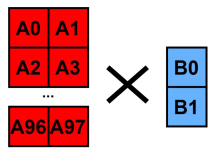
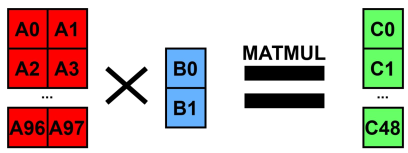

In [ ]:
# ----------------------
# 将矩阵拆分为 16×16 的子块，并显示 A 和 B 各自的第一个块

# 输入块矩阵 (Ai)（16×16）
block_input_matrix, input_block_col = matrix_split.matrix_splitting(input_matrix_padded, block_size, isWeight=False, isSquare=True)

# 权重块矩阵 (Bi)（16×16）
block_weight_matrix, weight_block_col = matrix_split.matrix_splitting(weight_matrix_padded, block_size, isWeight=True, isSquare=True)

print("A0 (",block_input_matrix[0].shape[0], "x", block_input_matrix[0].shape[1],") :\n\n", block_input_matrix[0], "\n")
print("B0 (",block_weight_matrix[0].shape[0], "x", block_weight_matrix[0].shape[1],") :\n\n", block_weight_matrix[0])

输入矩阵和权重矩阵的数据被编码到二进制文件 `input.bin` 和 `weight.bin` 中。
输入块的每一行是输入向量（16 字节），权重的 16×16 块（256 字节）是 VTA 使用的权重向量。

程序 `matrix_multiplication.py` 可用于预测 GeMM 后的输出矩阵 ACC，并将期望输出与模拟器的实际结果进行比对。

它还可以检索以二进制编码的输入数据（输入向量和权重矩阵），这些数据生成在 */compiler_output* 目录中，可直接用于模拟器。

*以 LeNet-5 第一卷积层 C1 为例：*

若 `user_configuration.py` 中设置 `doWriteBinaryFile=True`，运行以下命令将生成包含 A 块矩阵、转置后 B 块矩阵（输入数据）及期望输出（ACC）的二进制文件。

数据以小端格式（Little Endian）编码：第一个块的第一个向量 A0_0 编码为 16 字节序列，接着是 A0_1...直到 A0_15，然后是块 A1 的向量 A1_0、A1_1，依此类推，直到最后一个块的最后一个向量 A97_15。
B 以及其他数据类型（除非位宽超过 8 位，此时涉及字节反转）的编码方式相同。

以下文件将生成在 compiler_output/ 目录下：
- `input.bin`：A 的数据
- `weight.bin`：B 的数据
- `expected_out_sram.bin`：周期精确模拟的期望输出
- `out_init.bin`：空文件，由模拟输出覆盖
- `accumulator.bin`：模拟过程中用于累加数据的空文件
- `memory_addresses.csv`：每种数据类型（INP、WGT、OUT、UOP、ACC）的物理基地址

    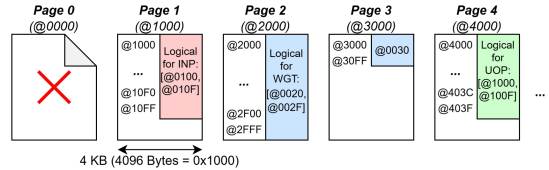

基地址根据向量大小和位宽计算。对于给定示例，数据在 DRAM 中的存储方式如下：

运行以下命令，在 /compiler_output 文件夹中生成二进制文件：

In [ ]:
%%capture
%run ../src/compiler/vta_compiler/data_definition/main_matrix_generator.py examples.data_lenet5_conv1